## Algorytm roju cząstek (PSO - particle swarm optimization)


## Zadania do samodzielnego wykonania

1.

Proszę, korzystając z algorytmu roju cząstek znaleźć minimum funkcji

$f(x,y)= 2ln(|𝑥+0.2|+0.002)+ln(|y+0.1|+0.001)+ cos(3x)+2sin^2(3xy)+sin^2(y)-x^2-0.5y^2 $

w przedziale $𝑥, 𝑦 ∈ [-1,1]$,  


przy założeniu że rozwiązanie jest reprezentowane przez wektor [𝑥𝑖, 𝑦𝑖].

Proszę zbadać:
- funkcjonowanie algorytmu dla c1=0, c2=2
- funkcjonowanie algorytmu dla c1=2, c2=0 oraz kilku przypadków pośrednich.
- funkcjonowanie algorytmu dla c1 = c2 = 2,2
- funkcjonowanie dla różnych wartości w.


Za każdym razem należy podać średnie wyniki (wartość funkcji przystosowania) oraz odchylenie standardowe dla 10 wywołań algorytmu i przedstawić przykładowe przebiegi algorytmu na wykresach (dla jednego z wywołań).

Należy opisać, który wariant sprawdzał się najlepiej.

2.

Uzyskany najlepszy wynik proszę w miarę możliwości porównać z algorytmem genetycznym – dedykowanym dla optymalizacji tej samej funkcji. Zakładamy użycie takiej samej liczby epok dla obu algorytmów.
Należy porównać czas działania obydwu algorytmów.

# Zadanie 1


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definicja funkcji celu
def fitness_function(X):
    x, y = X[0], X[1]
    term1 = 2 * np.log(np.abs(x + 0.2) + 0.002)
    term2 = np.log(np.abs(y + 0.1) + 0.001)
    term3 = np.cos(3 * x)
    term4 = 2 * np.sin(3 * x * y)**2
    term5 = np.sin(y)**2
    term6 = - x**2 - 0.5 * y**2
    return term1 + term2 + term3 + term4 + term5 + term6

# 2. Funkcja algorytmu PSO
def pso(c1, c2, w, num_particles=30, max_iter=100, bounds=([-1, 1], [-1, 1])):
    dim = len(bounds)
    
    # Inicjalizacja pozycji i prędkości
    X = np.random.uniform(bounds[0][0], bounds[0][1], (num_particles, dim))
    V = np.random.uniform(-0.1, 0.1, (num_particles, dim))
    
    pbest_X = X.copy()
    pbest_F = np.array([fitness_function(x) for x in X])
    
    gbest_idx = np.argmin(pbest_F)
    gbest_X = pbest_X[gbest_idx].copy()
    gbest_F = pbest_F[gbest_idx]
    
    history = []
    
    for _ in range(max_iter):
        r1 = np.random.rand(num_particles, dim)
        r2 = np.random.rand(num_particles, dim)
        
        # Aktualizacja prędkości cząstek (zgodnie ze standardowym wzorem PSO)
        V = w * V + c1 * r1 * (pbest_X - X) + c2 * r2 * (gbest_X - X)
        
        # Aktualizacja pozycji
        X = X + V
        
        # Ograniczenie wyjścia poza przedział [-1, 1]
        for d in range(dim):
            X[:, d] = np.clip(X[:, d], bounds[d][0], bounds[d][1])
            
        # Obliczanie funkcji przystosowania (fitness)
        current_F = np.array([fitness_function(x) for x in X])
        
        # Aktualizacja lokalnych najlepszych wyników (pbest)
        improve_idx = current_F < pbest_F
        pbest_X[improve_idx] = X[improve_idx]
        pbest_F[improve_idx] = current_F[improve_idx]
        
        # Aktualizacja globalnego najlepszego wyniku (gbest)
        if np.min(pbest_F) < gbest_F:
            gbest_idx = np.argmin(pbest_F)
            gbest_X = pbest_X[gbest_idx].copy()
            gbest_F = pbest_F[gbest_idx]
            
        history.append(gbest_F)
        
    return gbest_F, history

Wyniki eksperymentów (po 10 uruchomień):
--------------------------------------------------
Wariant [c1=0, c2=2, w=0.5]:
  Średnia (Mean) = -18.539478
  Odchylenie standardowe (Std) = 0.000000

Wariant [c1=2, c2=0, w=0.5]:
  Średnia (Mean) = -12.142353
  Odchylenie standardowe (Std) = 1.474631

Wariant [c1=1, c2=1, w=0.5]:
  Średnia (Mean) = -18.539478
  Odchylenie standardowe (Std) = 0.000000

Wariant [c1=0.5, c2=1.5, w=0.5]:
  Średnia (Mean) = -17.520383
  Odchylenie standardowe (Std) = 3.057271

Wariant [c1=2.2, c2=2.2, w=0.5]:
  Średnia (Mean) = -18.539185
  Odchylenie standardowe (Std) = 0.000483

Wariant [c1=2, c2=2, w=0.2]:
  Średnia (Mean) = -18.539478
  Odchylenie standardowe (Std) = 0.000000

Wariant [c1=2, c2=2, w=0.9]:
  Średnia (Mean) = -16.014501
  Odchylenie standardowe (Std) = 0.806768



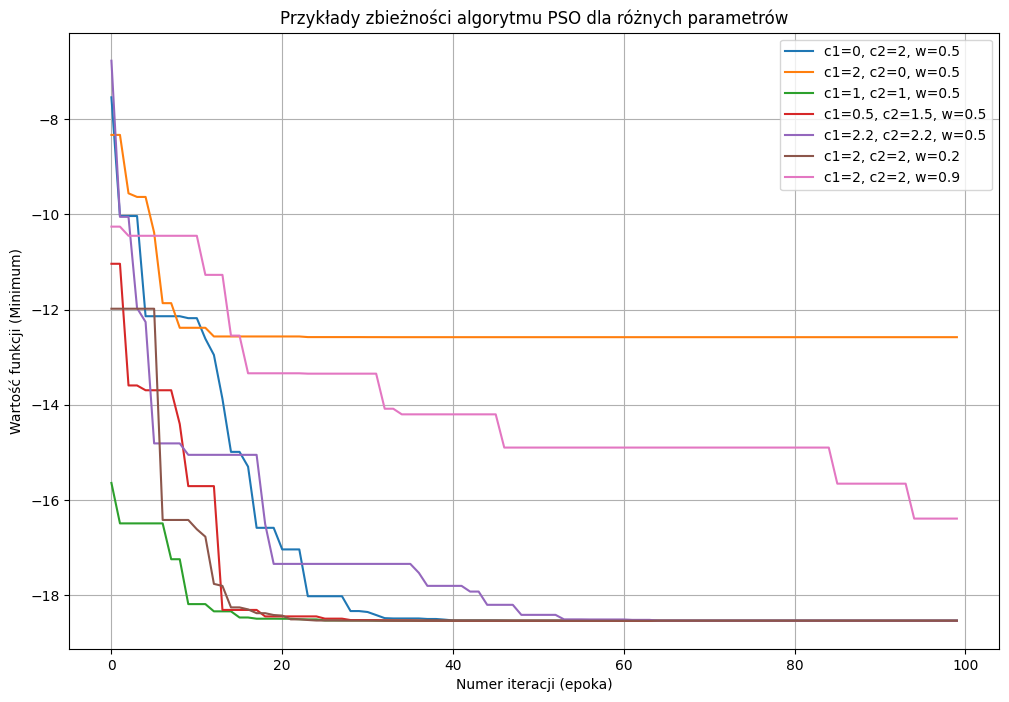

In [5]:
# Definicja wariantów parametrów do zbadania
variants = [
    {"name": "c1=0, c2=2, w=0.5", "c1": 0, "c2": 2, "w": 0.5},
    {"name": "c1=2, c2=0, w=0.5", "c1": 2, "c2": 0, "w": 0.5},
    {"name": "c1=1, c2=1, w=0.5", "c1": 1, "c2": 1, "w": 0.5},       # wariant pośredni
    {"name": "c1=0.5, c2=1.5, w=0.5", "c1": 0.5, "c2": 1.5, "w": 0.5}, # wariant pośredni
    {"name": "c1=2.2, c2=2.2, w=0.5", "c1": 2.2, "c2": 2.2, "w": 0.5},
    {"name": "c1=2, c2=2, w=0.2", "c1": 2, "c2": 2, "w": 0.2},       # małe w
    {"name": "c1=2, c2=2, w=0.9", "c1": 2, "c2": 2, "w": 0.9}        # duże w
]

num_runs = 10
results = {}

print("Wyniki eksperymentów (po 10 uruchomień):")
print("-" * 50)

for var in variants:
    best_fitnesses = []
    histories = []
    
    for _ in range(num_runs):
        best_f, hist = pso(var['c1'], var['c2'], var['w'])
        best_fitnesses.append(best_f)
        histories.append(hist)
        
    mean_f = np.mean(best_fitnesses)
    std_f = np.std(best_fitnesses)
    
    # Zapisujemy pierwszą historię do wykresu jako przykład
    results[var['name']] = histories[0] 
    
    print(f"Wariant [{var['name']}]:")
    print(f"  Średnia (Mean) = {mean_f:.6f}")
    print(f"  Odchylenie standardowe (Std) = {std_f:.6f}\n")

# Tworzenie wykresów zbieżności (jeden przykład z 10 dla każdego wariantu)
plt.figure(figsize=(12, 8))
for name, history in results.items():
    plt.plot(history, label=name)

plt.title("Przykłady zbieżności algorytmu PSO dla różnych parametrów")
plt.xlabel("Numer iteracji (epoka)")
plt.ylabel("Wartość funkcji (Minimum)")
plt.legend()
plt.grid(True)
plt.show()

# Zadanie 2


In [3]:
import numpy as np
import time

# 1. Funkcja przystosowania (funkcja celu)
def fitness_function(X):
    x, y = X[0], X[1]
    term1 = 2 * np.log(np.abs(x + 0.2) + 0.002)
    term2 = np.log(np.abs(y + 0.1) + 0.001)
    term3 = np.cos(3 * x)
    term4 = 2 * np.sin(3 * x * y)**2
    term5 = np.sin(y)**2
    term6 = - x**2 - 0.5 * y**2
    return term1 + term2 + term3 + term4 + term5 + term6

# 2. Algorytm PSO (wersja bazowa do porównania)
def pso_compare(num_particles=30, max_iter=100, bounds=([-1, 1], [-1, 1])):
    w, c1, c2 = 0.5, 1.5, 1.5
    dim = len(bounds)
    X = np.random.uniform(bounds[0][0], bounds[0][1], (num_particles, dim))
    V = np.random.uniform(-0.1, 0.1, (num_particles, dim))
    pbest_X = X.copy()
    pbest_F = np.array([fitness_function(x) for x in X])
    gbest_idx = np.argmin(pbest_F)
    gbest_F = pbest_F[gbest_idx]
    
    for _ in range(max_iter):
        r1 = np.random.rand(num_particles, dim)
        r2 = np.random.rand(num_particles, dim)
        
        # Wektoryzowana aktualizacja prędkości
        gbest_X = pbest_X[np.argmin(pbest_F)]
        V = w * V + c1 * r1 * (pbest_X - X) + c2 * r2 * (gbest_X - X)
        X = X + V
        
        for d in range(dim):
            X[:, d] = np.clip(X[:, d], bounds[d][0], bounds[d][1])
            
        current_F = np.array([fitness_function(x) for x in X])
        improve_idx = current_F < pbest_F
        pbest_X[improve_idx] = X[improve_idx]
        pbest_F[improve_idx] = current_F[improve_idx]
        if np.min(pbest_F) < gbest_F:
            gbest_F = np.min(pbest_F)
            
    return gbest_F

# 3. Algorytm genetyczny (GA) dla liczb rzeczywistych
def genetic_algorithm(pop_size=30, max_iter=100, bounds=([-1, 1], [-1, 1])):
    dim = len(bounds)
    mutation_rate = 0.1
    
    # Inicjalizacja populacji
    population = np.random.uniform(bounds[0][0], bounds[0][1], (pop_size, dim))
    best_F = float('inf')
    
    for _ in range(max_iter):
        fitness = np.array([fitness_function(ind) for ind in population])
        
        # Zapamiętanie najlepszego rozwiązania
        current_best = np.min(fitness)
        if current_best < best_F:
            best_F = current_best
            
        # Selekcja turniejowa
        new_population = np.zeros_like(population)
        for i in range(pop_size):
            # Wybieramy 3 losowe osobniki i bierzemy najlepszego
            tournament = np.random.choice(pop_size, 3, replace=False)
            winner_idx = tournament[np.argmin(fitness[tournament])]
            new_population[i] = population[winner_idx]
            
        # Krzyżowanie arytmetyczne (crossover)
        for i in range(0, pop_size - 1, 2):
            if np.random.rand() < 0.7: # Prawdopodobieństwo krzyżowania 70%
                alpha = np.random.rand()
                parent1, parent2 = new_population[i].copy(), new_population[i+1].copy()
                new_population[i] = alpha * parent1 + (1 - alpha) * parent2
                new_population[i+1] = alpha * parent2 + (1 - alpha) * parent1
                
        # Mutacja (dodanie losowego szumu)
        for i in range(pop_size):
            if np.random.rand() < mutation_rate:
                mutation_val = np.random.uniform(-0.2, 0.2, dim)
                new_population[i] += mutation_val
                
        # Ograniczenia obszaru poszukiwań
        for d in range(dim):
            new_population[:, d] = np.clip(new_population[:, d], bounds[d][0], bounds[d][1])
            
        population = new_population
        
    return best_F

# 4. Porównanie wydajności
epochs = 100
population_size = 30
runs = 10

pso_times, ga_times = [], []
pso_results, ga_results = [], []

print(f"Porównanie PSO i GA (Epoki: {epochs}, Rozmiar populacji: {population_size})")
print("Trwają obliczenia...")

for _ in range(runs):
    # Test PSO
    start_time = time.time()
    best_pso = pso_compare(num_particles=population_size, max_iter=epochs)
    pso_times.append(time.time() - start_time)
    pso_results.append(best_pso)
    
    # Test GA
    start_time = time.time()
    best_ga = genetic_algorithm(pop_size=population_size, max_iter=epochs)
    ga_times.append(time.time() - start_time)
    ga_results.append(best_ga)

print("-" * 50)
print("Wyniki (średnia z 10 uruchomień):")
print(f"PSO Średnie minimum: {np.mean(pso_results):.6f} (Odchylenie standardowe: {np.std(pso_results):.6f})")
print(f"GA  Średnie minimum: {np.mean(ga_results):.6f} (Odchylenie standardowe: {np.std(ga_results):.6f})")
print("-" * 50)
print(f"PSO Średni czas wykonania: {np.mean(pso_times):.6f} sek")
print(f"GA  Średni czas wykonania: {np.mean(ga_times):.6f} sek")

Porównanie PSO i GA (Epoki: 100, Rozmiar populacji: 30)
Trwają obliczenia...
--------------------------------------------------
Wyniki (średnia z 10 uruchomień):
PSO Średnie minimum: -18.539478 (Odchylenie standardowe: 0.000000)
GA  Średnie minimum: -14.991989 (Odchylenie standardowe: 1.732998)
--------------------------------------------------
PSO Średni czas wykonania: 0.026640 sek
GA  Średni czas wykonania: 0.086371 sek
